# Conclusion

This notebook developed and evaluated multiple machine learning models for weekly sales forecasting.

Models evaluated:

- Linear Regression
- Random Forest
- Gradient Boosting
- XGBoost

Based on evaluation metrics, **Random Forest** achieved the best overall performance with the highest R² score and the lowest prediction errors.

The trained Random Forest model and its feature list have been saved for integration into the RetailPulse dashboard.

In [32]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    rf_model,
    "../models/sales_forecasting_model.pkl"
)

joblib.dump(
    feature_columns,
    "../models/sales_forecasting_features.pkl"
)

print("Model saved successfully.")

Model saved successfully.


,Feature,Importance
4,Lag_1,0.497762
0,WeekOfYear,0.106583
1,Month,0.103279
6,Lag_4,0.098198
7,RollingMean_4,0.049068
5,Lag_2,0.036115
10,Week_Cos,0.028855
8,RollingStd_4,0.026725
2,Quarter,0.025870
9,Week_Sin,0.024137


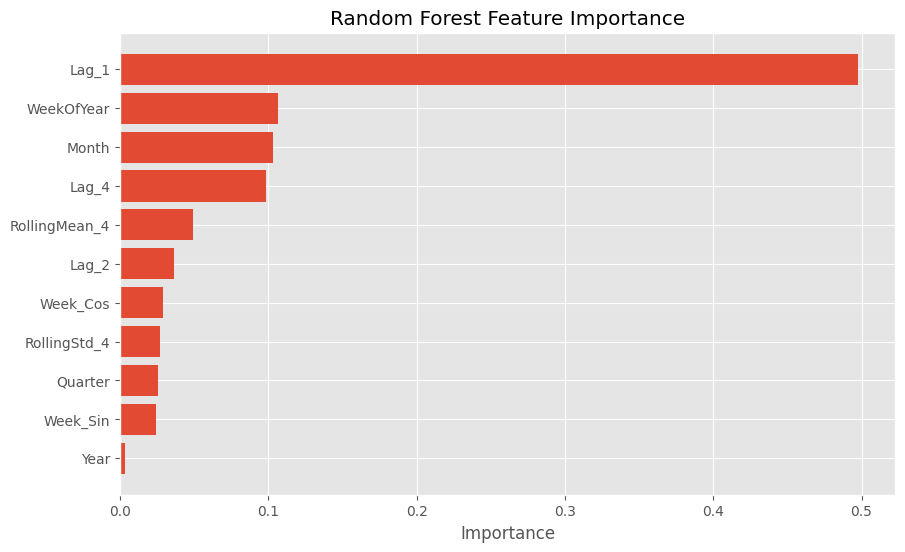

In [31]:
importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

In [30]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae,
        xgb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2,
        gb_r2,
        xgb_r2
    ]
})

comparison = comparison.sort_values("R2 Score", ascending=False)

display(comparison)

,Model,MAE,RMSE,R2 Score
1,Random Forest,44654.098039,55670.873539,0.604934
2,Gradient Boosting,47097.175534,58387.805260,0.565432
0,Linear Regression,46329.595359,63628.636894,0.483918
3,XGBoost,53228.554036,67547.479599,0.418390


## Step 10: Model Comparison

The forecasting models are compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The best-performing model is selected for deployment.

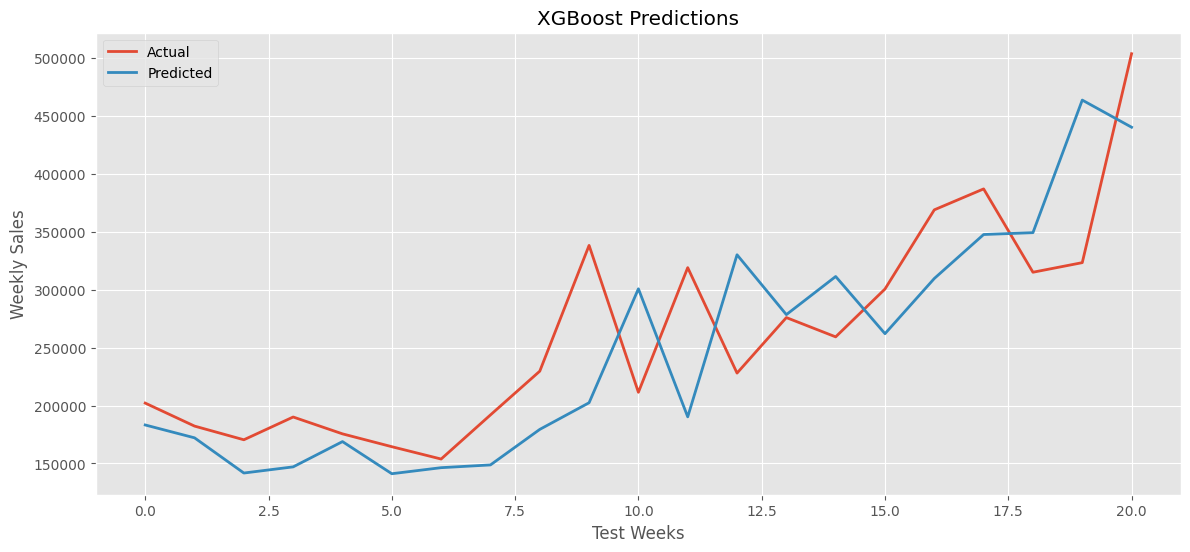

In [29]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(xgb_predictions, label="Predicted", linewidth=2)

plt.title("XGBoost Predictions")
plt.xlabel("Test Weeks")
plt.ylabel("Weekly Sales")

plt.legend()
plt.grid(True)

plt.show()

In [28]:
comparison_xgb = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_predictions
})

display(comparison_xgb.head(10))

,Actual,Predicted
0,202130.170,183237.703125
1,182275.231,172139.984375
2,170460.170,141748.093750
3,190121.410,147067.406250
4,175570.680,168883.531250
5,164484.130,141149.343750
6,153830.630,146367.203125
7,191912.070,148741.453125
8,229688.160,179415.218750
9,338294.081,202434.296875


In [27]:
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print("=" * 50)
print("XGBoost Performance")
print("=" * 50)

print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Performance
MAE  : 53228.55
RMSE : 67547.48
R²   : 0.4184


In [26]:
# XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=RANDOM_STATE
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


## Step 9: XGBoost Regression

Extreme Gradient Boosting (XGBoost) is an optimized boosting algorithm designed for high predictive performance, speed, and regularization.

It is commonly one of the strongest models for structured business datasets.

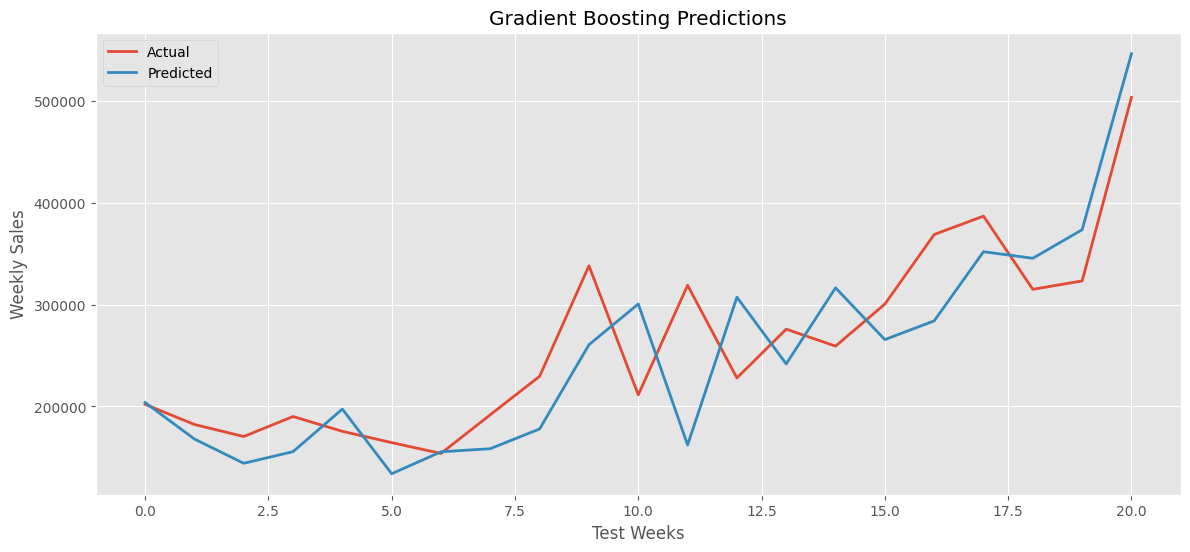

In [25]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    gb_predictions,
    label="Predicted",
    linewidth=2
)

plt.title("Gradient Boosting Predictions")
plt.xlabel("Test Weeks")
plt.ylabel("Weekly Sales")

plt.legend()
plt.grid(True)

plt.show()

In [24]:
comparison_gb = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": gb_predictions
})

display(comparison_gb.head(10))

,Actual,Predicted
0,202130.170,203893.807082
1,182275.231,168017.977531
2,170460.170,144155.721283
3,190121.410,155599.415717
4,175570.680,197427.154763
5,164484.130,133899.512123
6,153830.630,155414.424309
7,191912.070,158503.165968
8,229688.160,177916.889154
9,338294.081,260687.367853


In [23]:
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
gb_r2 = r2_score(y_test, gb_predictions)

print("=" * 50)
print("Gradient Boosting Performance")
print("=" * 50)

print(f"MAE  : {gb_mae:.2f}")
print(f"RMSE : {gb_rmse:.2f}")
print(f"R²   : {gb_r2:.4f}")

Gradient Boosting Performance
MAE  : 47097.18
RMSE : 58387.81
R²   : 0.5654


In [22]:
# Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=RANDOM_STATE
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


## Step 8: Gradient Boosting Regression

Gradient Boosting builds decision trees sequentially, where each new tree attempts to correct the errors made by the previous trees.

It often provides better predictive performance than Random Forest on structured tabular datasets.

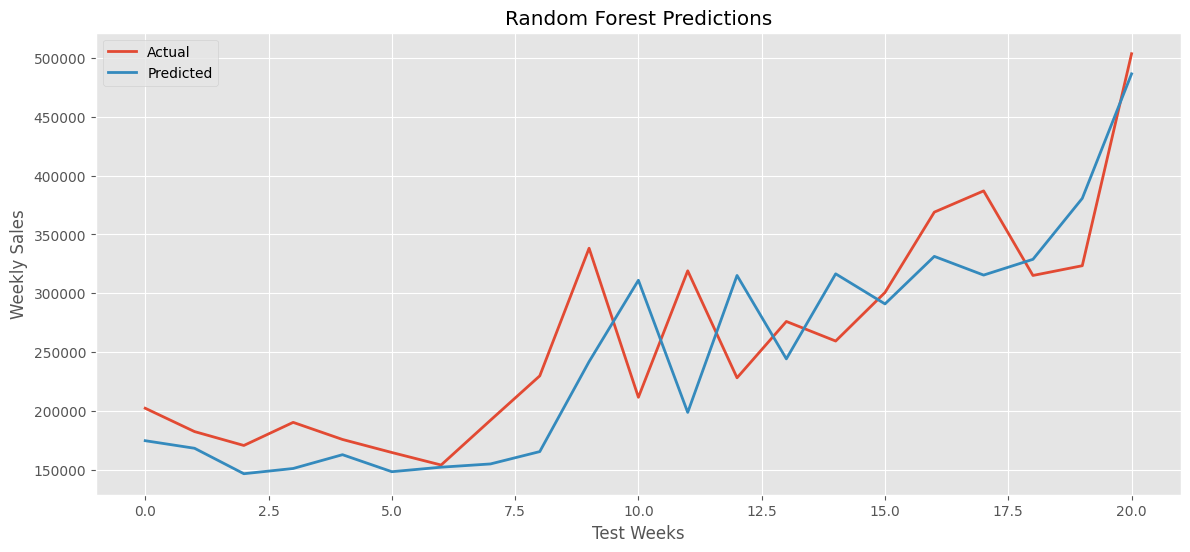

In [21]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    rf_predictions,
    label="Predicted",
    linewidth=2
)

plt.title("Random Forest Predictions")
plt.xlabel("Test Weeks")
plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

In [20]:
comparison_rf = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_predictions
})

display(comparison_rf.head(10))

,Actual,Predicted
0,202130.170,174513.516863
1,182275.231,168079.075642
2,170460.170,146421.450049
3,190121.410,150880.438924
4,175570.680,162613.827476
5,164484.130,148148.722142
6,153830.630,151980.028340
7,191912.070,154741.431235
8,229688.160,165248.838992
9,338294.081,241782.494162


In [19]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("=" * 50)
print("Random Forest Performance")
print("=" * 50)

print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
MAE  : 44654.10
RMSE : 55670.87
R²   : 0.6049


In [18]:
# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Step 7: Random Forest Regression

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

It is expected to outperform Linear Regression by capturing non-linear relationships in the sales data.

In [17]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("=" * 50)
print("Linear Regression Performance")
print("=" * 50)

print(f"MAE  : {linear_mae:.2f}")
print(f"RMSE : {linear_rmse:.2f}")
print(f"R²   : {linear_r2:.4f}")

Linear Regression Performance
MAE  : 46329.60
RMSE : 63628.64
R²   : 0.4839


In [16]:
# Train Linear Regression
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Step 6: Linear Regression

Linear Regression serves as the baseline forecasting model.

The performance of advanced ensemble models will later be compared against this baseline.

In [15]:
# Features used for forecasting
feature_columns = [
    "WeekOfYear",
    "Month",
    "Quarter",
    "Year",
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "RollingMean_4",
    "RollingStd_4",
    "Week_Sin",
    "Week_Cos"
]

X = weekly_sales[feature_columns]
y = weekly_sales["WeeklySales"]

# Chronological train-test split
split_index = int(len(weekly_sales) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 81
Testing Samples  : 21


## Step 5: Train-Test Split

The dataset is split into training and testing sets while preserving the chronological order.

Since this is a time-series forecasting problem, we do **not** shuffle the data.

In [14]:
# Cyclical Encoding
weekly_sales["Week_Sin"] = np.sin(
    2 * np.pi * weekly_sales["WeekOfYear"] / 52
)

weekly_sales["Week_Cos"] = np.cos(
    2 * np.pi * weekly_sales["WeekOfYear"] / 52
)

# Remove rows with NaN values created by lag and rolling features
weekly_sales = weekly_sales.dropna().reset_index(drop=True)

print(f"Final Dataset Shape : {weekly_sales.shape}")

display(weekly_sales.head())

Final Dataset Shape : (102, 13)


,Week,WeeklySales,WeekOfYear,Month,Quarter,Year,Lag_1,Lag_2,Lag_4,RollingMean_4,RollingStd_4,Week_Sin,Week_Cos
0,2010-01-03,0.000,53,1,1,2010,55189.580,260473.31,266304.65,205620.98750,100893.645409,0.120537,0.992709
1,2010-01-10,168228.580,1,1,1,2010,0.000,55189.58,240516.41,139044.82500,130902.667410,0.120537,0.992709
2,2010-01-17,163595.570,2,1,1,2010,168228.580,0.00,260473.31,120972.86750,116412.129103,0.239316,0.970942
3,2010-01-24,153725.871,3,1,1,2010,163595.570,168228.58,55189.58,96753.43250,82996.683851,0.354605,0.935016
4,2010-01-31,165605.091,4,1,1,2010,153725.871,163595.57,0.00,121387.50525,81150.689757,0.464723,0.885456


In [13]:
# Rolling statistics using only previous observations
weekly_sales["RollingMean_4"] = (
    weekly_sales["WeeklySales"]
    .shift(1)
    .rolling(window=4)
    .mean()
)

weekly_sales["RollingStd_4"] = (
    weekly_sales["WeeklySales"]
    .shift(1)
    .rolling(window=4)
    .std()
)

weekly_sales.head(10)

,Week,WeeklySales,WeekOfYear,Month,Quarter,Year,Lag_1,Lag_2,Lag_4,RollingMean_4,RollingStd_4
0,2009-12-06,266304.650,49,12,4,2009,NaN,NaN,NaN,NaN,NaN
1,2009-12-13,240516.410,50,12,4,2009,266304.650,NaN,NaN,NaN,NaN
2,2009-12-20,260473.310,51,12,4,2009,240516.410,266304.650,NaN,NaN,NaN
3,2009-12-27,55189.580,52,12,4,2009,260473.310,240516.410,NaN,NaN,NaN
4,2010-01-03,0.000,53,1,1,2010,55189.580,260473.310,266304.65,205620.98750,100893.645409
5,2010-01-10,168228.580,1,1,1,2010,0.000,55189.580,240516.41,139044.82500,130902.667410
6,2010-01-17,163595.570,2,1,1,2010,168228.580,0.000,260473.31,120972.86750,116412.129103
7,2010-01-24,153725.871,3,1,1,2010,163595.570,168228.580,55189.58,96753.43250,82996.683851
8,2010-01-31,165605.091,4,1,1,2010,153725.871,163595.570,0.00,121387.50525,81150.689757
9,2010-02-07,124084.092,5,2,1,2010,165605.091,153725.871,168228.58,162788.77800,6332.726146


In [12]:
# Historical Sales Features
weekly_sales["Lag_1"] = weekly_sales["WeeklySales"].shift(1)
weekly_sales["Lag_2"] = weekly_sales["WeeklySales"].shift(2)
weekly_sales["Lag_4"] = weekly_sales["WeeklySales"].shift(4)

weekly_sales.head(10)

,Week,WeeklySales,WeekOfYear,Month,Quarter,Year,Lag_1,Lag_2,Lag_4
0,2009-12-06,266304.650,49,12,4,2009,NaN,NaN,NaN
1,2009-12-13,240516.410,50,12,4,2009,266304.650,NaN,NaN
2,2009-12-20,260473.310,51,12,4,2009,240516.410,266304.650,NaN
3,2009-12-27,55189.580,52,12,4,2009,260473.310,240516.410,NaN
4,2010-01-03,0.000,53,1,1,2010,55189.580,260473.310,266304.65
5,2010-01-10,168228.580,1,1,1,2010,0.000,55189.580,240516.41
6,2010-01-17,163595.570,2,1,1,2010,168228.580,0.000,260473.31
7,2010-01-24,153725.871,3,1,1,2010,163595.570,168228.580,55189.58
8,2010-01-31,165605.091,4,1,1,2010,153725.871,163595.570,0.00
9,2010-02-07,124084.092,5,2,1,2010,165605.091,153725.871,168228.58


In [11]:
# Calendar Features
weekly_sales["WeekOfYear"] = weekly_sales["Week"].dt.isocalendar().week.astype(int)
weekly_sales["Month"] = weekly_sales["Week"].dt.month
weekly_sales["Quarter"] = weekly_sales["Week"].dt.quarter
weekly_sales["Year"] = weekly_sales["Week"].dt.year

weekly_sales.head()

,Week,WeeklySales,WeekOfYear,Month,Quarter,Year
0,2009-12-06,266304.65,49,12,4,2009
1,2009-12-13,240516.41,50,12,4,2009
2,2009-12-20,260473.31,51,12,4,2009
3,2009-12-27,55189.58,52,12,4,2009
4,2010-01-03,0.00,53,1,1,2010


## Step 4: Feature Engineering

To improve forecasting accuracy, we create several time-series features:

- Lag Features
- Rolling Statistics
- Calendar Features
- Cyclical Features

These features enable the model to learn historical trends and seasonal patterns while preventing data leakage.

In [10]:
print("=" * 60)
print("Weekly Sales Statistics")
print("=" * 60)

display(weekly_sales.describe())

print("\nHighest Weekly Sales :")
display(weekly_sales.nlargest(5, "WeeklySales"))

print("\nLowest Weekly Sales :")
display(weekly_sales.nsmallest(5, "WeeklySales"))

Weekly Sales Statistics


,Week,WeeklySales
count,106,106.000000
mean,2010-12-08 12:00:00,197300.862906
min,2009-12-06 00:00:00,0.000000
25%,2010-06-07 18:00:00,145566.592500
50%,2010-12-08 12:00:00,170865.640000
75%,2011-06-10 06:00:00,219896.400000
max,2011-12-11 00:00:00,582069.770000
std,NaN,92758.022230



Highest Weekly Sales :


,Week,WeeklySales
53,2010-12-12,582069.770
52,2010-12-05,508301.640
105,2011-12-11,503785.750
102,2011-11-20,387064.650
49,2010-11-14,380781.021



Lowest Weekly Sales :


,Week,WeeklySales
4,2010-01-03,0.00
56,2011-01-02,0.00
3,2009-12-27,55189.58
73,2011-05-01,86364.58
10,2010-02-14,90814.12


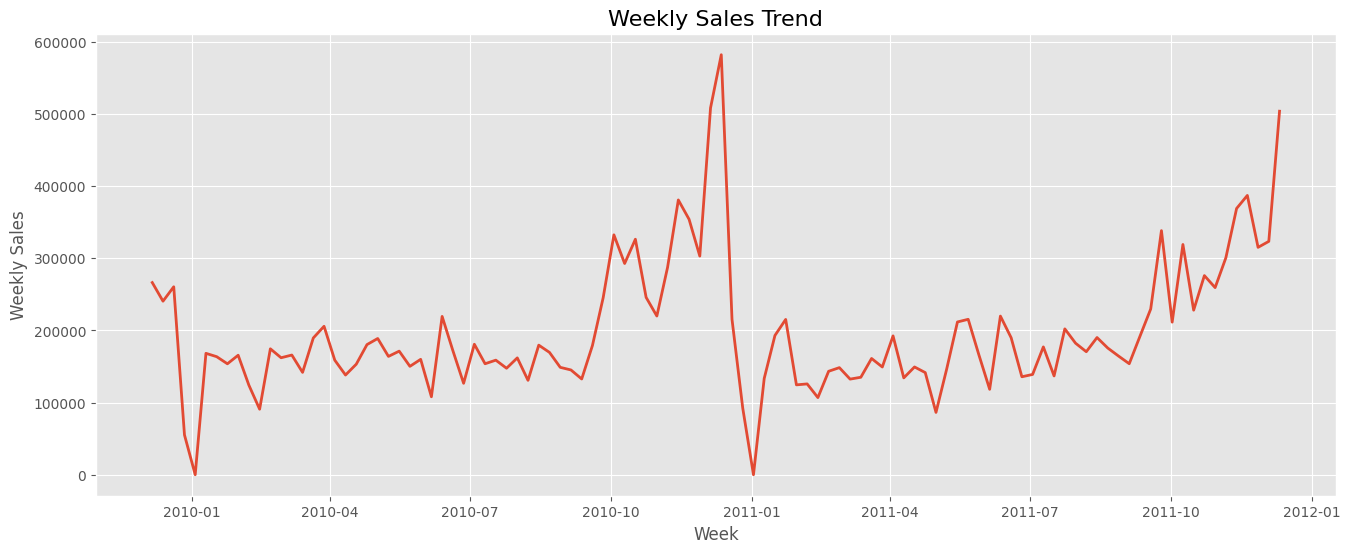

In [9]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales["Week"],
    weekly_sales["WeeklySales"],
    linewidth=2
)

plt.title("Weekly Sales Trend", fontsize=16)
plt.xlabel("Week")
plt.ylabel("Weekly Sales")
plt.grid(True)

plt.show()

## Step 3: Exploratory Data Analysis

Before building forecasting models, we visualize weekly sales trends to understand seasonality, fluctuations, and long-term patterns.

In [8]:
# Create TotalSales column if it doesn't already exist
if "TotalSales" not in df.columns:
    df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

# Create weekly sales dataset
weekly_sales = (
    df
    .set_index("InvoiceDate")
    .resample("W")["TotalSales"]
    .sum()
    .reset_index()
)

weekly_sales.columns = ["Week", "WeeklySales"]

print(f"Number of Weeks : {len(weekly_sales)}")

display(weekly_sales.head())

Number of Weeks : 106


,Week,WeeklySales
0,2009-12-06,266304.65
1,2009-12-13,240516.41
2,2009-12-20,260473.31
3,2009-12-27,55189.58
4,2010-01-03,0.00


## Step 2: Create Weekly Sales Data

Since sales forecasting is a time-series problem, transaction-level data is aggregated into weekly sales.

Weekly aggregation helps capture long-term business trends while reducing daily fluctuations.

In [7]:
# Load processed dataset
df = pd.read_csv("../data/processed/retail_cleaned.csv")

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset loaded successfully.\n")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

display(df.head())

Dataset loaded successfully.

Rows    : 1,029,609
Columns : 15


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,MonthName,Day,Weekday,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,1,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,1,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,1,Tuesday,7


In [6]:
import os

print(os.listdir("../data/processed"))

['analysis_data.csv', 'churn_dataset.csv', 'customer_features.csv', 'retail_cleaned.csv', 'rfm_data.csv']


In [5]:
import os

print(os.getcwd())

c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\notebooks


## Step 1: Load Processed Dataset

The cleaned dataset created in Notebook 01 is loaded for forecasting analysis.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor

plt.style.use("ggplot")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


# 📈 Notebook 04: Sales Forecasting

## Objective

The objective of this notebook is to forecast future weekly sales using historical transaction data from the Online Retail II dataset.

We will:

- Load the processed retail dataset
- Perform time-series aggregation
- Explore weekly sales trends
- Engineer time-series features
- Train multiple regression models
- Compare model performance
- Select the best forecasting model for deployment